In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv("pilot_regret_data_hybrid.csv")

In [3]:
data.head()

,fen,ref_nodes,ref_bestmove,ref_root_score_type,ref_root_score_value,ref_depth,ref_seldepth,ref_bestmove_ref_score_type,ref_bestmove_ref_score_value,label_bucket,...,bucket_200000_regret_cp,bucket_800000_bestmove,bucket_800000_root_score_type,bucket_800000_root_score_value,bucket_800000_depth,bucket_800000_seldepth,bucket_800000_same_move,bucket_800000_move_ref_score_type,bucket_800000_move_ref_score_value,bucket_800000_regret_cp
0,r2q1rk1/ppp2ppp/2np1n2/2b1p3/4P1b1/1BPP1N2/PP3...,1600000,h2h3,cp,35,26,32,cp,32,50000,...,0,h2h3,cp,32,26,34,True,cp,32,0
1,r2q1rk1/pp1nbppp/2p1pn2/3p1b2/2PP1B2/2N1PN2/PP...,1600000,f3h4,cp,19,23,36,cp,17,50000,...,0,h2h3,cp,20,23,28,False,cp,24,0
2,2r5/8/7R/1P2kp2/2P1pp2/2K5/5PPP/8 b - -,1600000,c8d8,cp,377,21,40,cp,-404,50000,...,0,e4e3,cp,400,20,28,False,cp,-443,39
3,4rrk1/R5bp/3qp1p1/3p3n/2pB1P2/5BPP/1P3P2/3QR1K...,1600000,g7d4,cp,114,24,44,cp,-124,50000,...,0,g7d4,cp,114,22,36,True,cp,-124,0
4,2kr3r/ppp1n1pp/2nq1p2/8/3P2b1/1Q2BN2/PP2BPPP/R...,1600000,g4e6,cp,-47,22,25,cp,33,50000,...,0,g4e6,cp,-41,22,34,True,cp,33,0


In [4]:
cp_diff_cols = [c for c in data.columns if c.endswith("_regret_cp")]
cp_diff_cols

['bucket_50000_regret_cp',
 'bucket_200000_regret_cp',
 'bucket_800000_regret_cp']

In [5]:
summary = data[cp_diff_cols].describe().T
summary[["count", "mean", "50%", "std", "min", "max"]]

,count,mean,50%,std,min,max
bucket_50000_regret_cp,673.0,5.242199,0.0,98.613102,0.0,2524.0
bucket_200000_regret_cp,673.0,6.765230,0.0,106.452740,0.0,2524.0
bucket_800000_regret_cp,673.0,2.102526,0.0,38.990764,0.0,1000.0


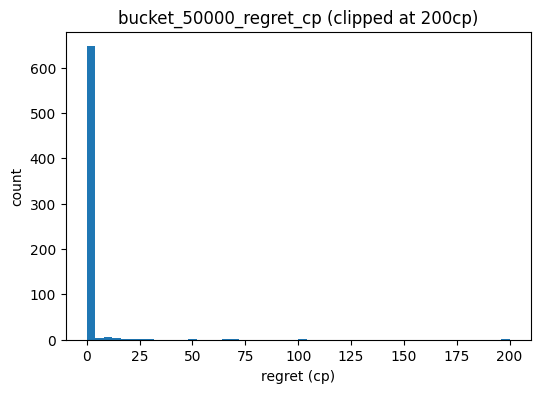

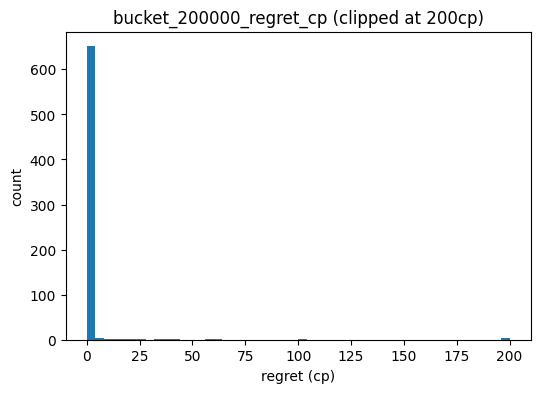

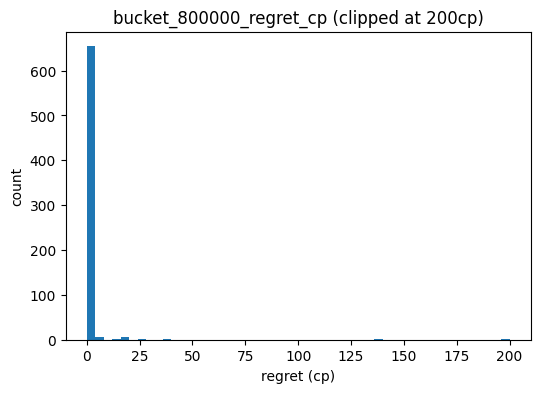

In [6]:
for col in cp_diff_cols:
    plt.figure(figsize=(6,4))
    
    vals = data[col].dropna()
    vals = vals.clip(0, 200)   # remove extreme outliers
    
    plt.hist(vals, bins=50)
    plt.title(f"{col} (clipped at 200cp)")
    plt.xlabel("regret (cp)")
    plt.ylabel("count")
    plt.show()

C:\Users\khoo\AppData\Local\Temp\ipykernel_111360\1969348163.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(plot_data, labels=cp_diff_cols, showfliers=False)


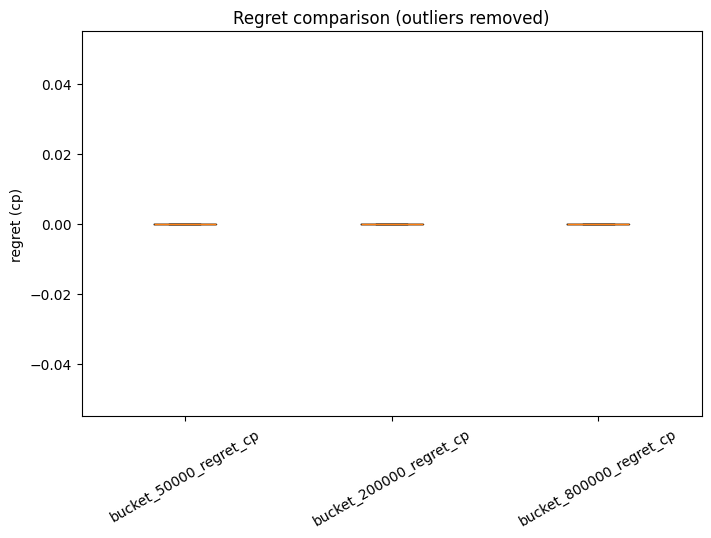

In [7]:
plot_data = [data[col].dropna().clip(0, 200) for col in cp_diff_cols]

plt.figure(figsize=(8,5))
plt.boxplot(plot_data, labels=cp_diff_cols, showfliers=False)
plt.ylabel("regret (cp)")
plt.title("Regret comparison (outliers removed)")
plt.xticks(rotation=30)
plt.show()

In [8]:
medians = data[cp_diff_cols].median()
means = data[cp_diff_cols].mean()

print("Median:\n", medians)
print("\nMean:\n", means)

Median:
 bucket_50000_regret_cp     0.0
bucket_200000_regret_cp    0.0
bucket_800000_regret_cp    0.0
dtype: float64

Mean:
 bucket_50000_regret_cp     5.242199
bucket_200000_regret_cp    6.765230
bucket_800000_regret_cp    2.102526
dtype: float64


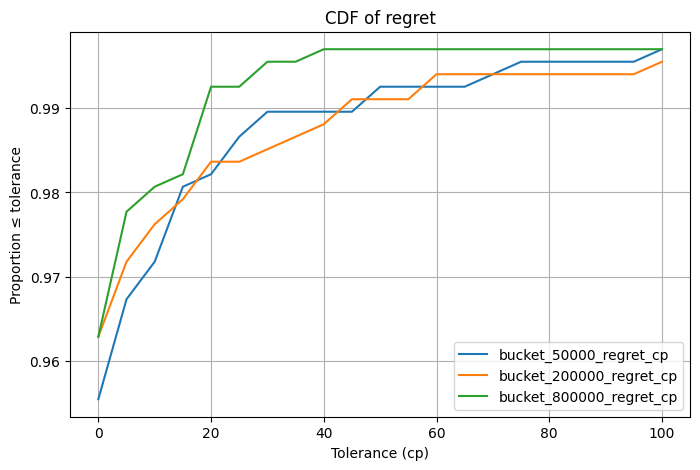

In [9]:
tolerances = np.arange(0, 101, 5)

plt.figure(figsize=(8,5))

for col in cp_diff_cols:
    vals = data[col].dropna().clip(0, 200)
    
    proportions = [(vals <= t).mean() for t in tolerances]
    
    plt.plot(tolerances, proportions, label=col)

plt.xlabel("Tolerance (cp)")
plt.ylabel("Proportion ≤ tolerance")
plt.title("CDF of regret")
plt.legend()
plt.grid()
plt.show()